# Notebook d'analyse acoustique

- Conversion en numérique + suppression conjointe des NaN
- Alignement explicite des longueurs pour éviter les erreurs `ValueError` au tracé


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
plt.rcParams.update({'figure.figsize': (12,6)})

{'nb': 2048, 'Fs_estimee_Hz': np.float64(48000.00767999116)}


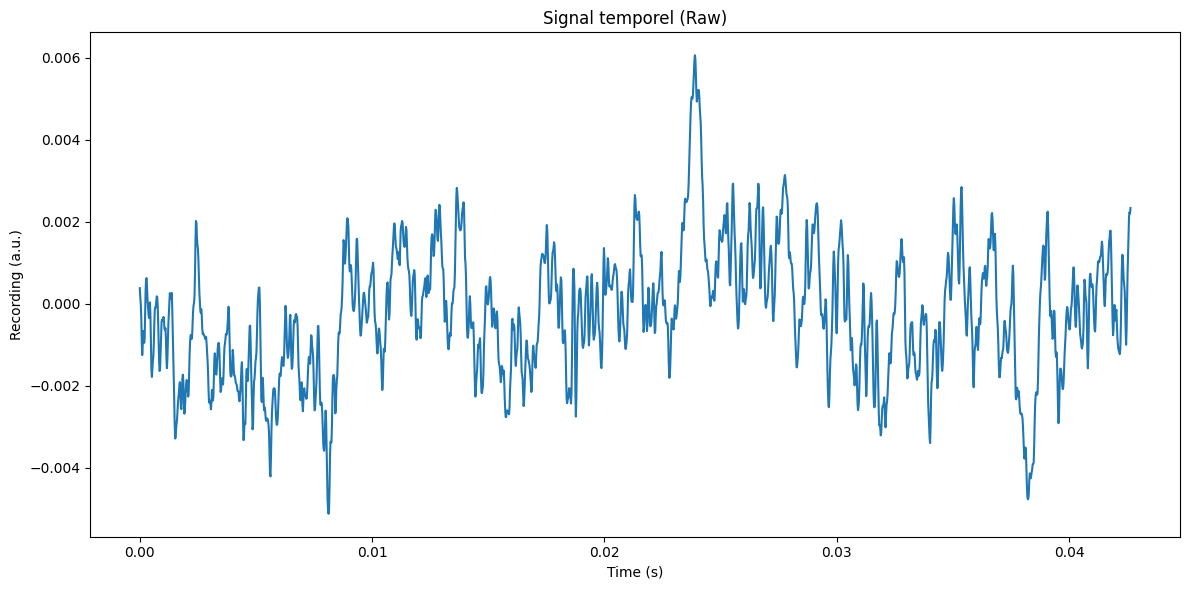

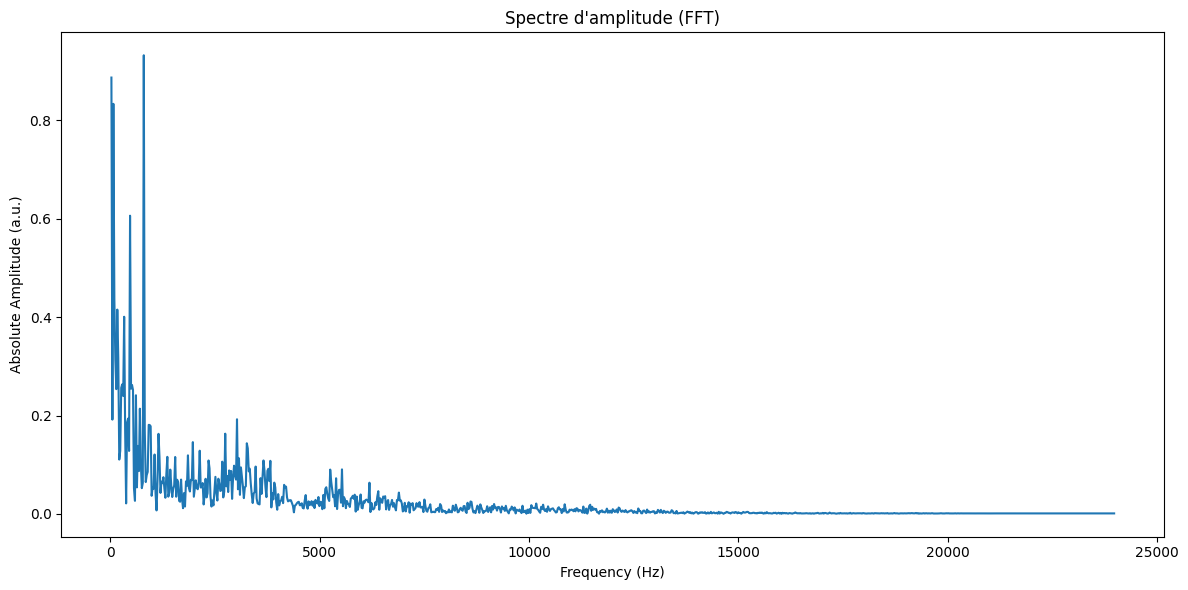

{'f_pic_Hz': 796.875, 'SNR_dB_simple': np.float64(49.89269956776171)}


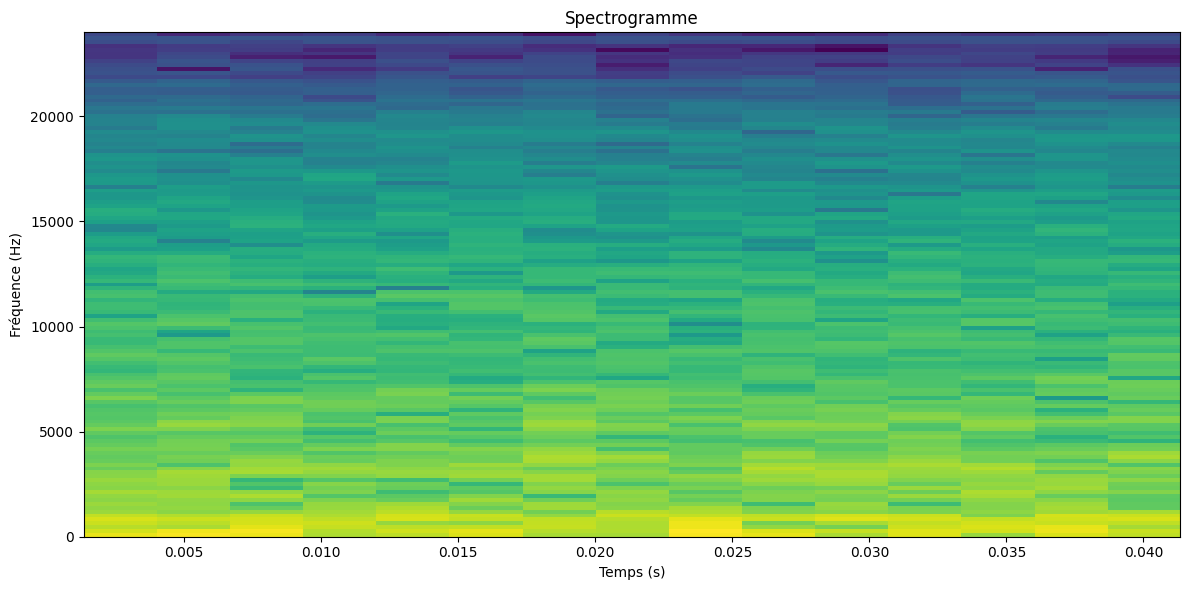

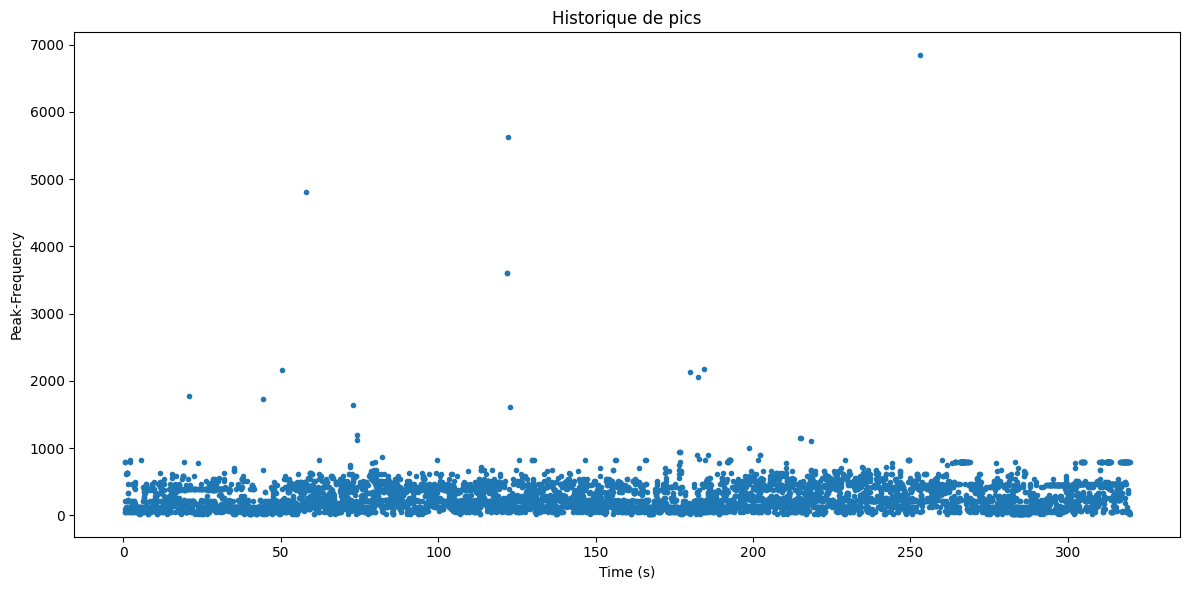

In [ ]:
RAW_PATH  = Path('Raw data.csv')
FFT_PATH  = Path('FFT Spectrum.csv')
PEAK_PATH = Path('Peak History.csv')

def read_csv_safe(path):
    if not path.exists():
        name = path.name.lower()
        if 'raw' in name:
            t = np.linspace(0, 1, 2048)
            x = np.sin(2 * np.pi * 120 * t) + 0.05 * np.random.randn(len(t))
            return pd.DataFrame({'time_s': t, 'amplitude': x})
        if 'fft' in name:
            f = np.linspace(0, 500, 1024)
            A = 0.01 * np.ones_like(f)
            idx = (np.abs(f - 120)).argmin()
            A[idx] = 1.0
            return pd.DataFrame({'frequency_Hz': f, 'amplitude': A})
        if 'peak' in name:
            tp = np.linspace(0, 10, 5)
            fp = np.full_like(tp, 120.0)
            return pd.DataFrame({'time': tp, 'peak_Hz': fp})
        return pd.DataFrame()

    try:
        return pd.read_csv(path)
    except Exception:
        try:
            return pd.read_csv(path, sep=';')
        except Exception:
            return pd.read_csv(path, encoding='latin-1')

def coerce_numeric(df, cols):
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    return df

raw = read_csv_safe(RAW_PATH)
fft = read_csv_safe(FFT_PATH)
peaks = read_csv_safe(PEAK_PATH)

# RAW
if raw.shape[1] < 2:
    raw = pd.DataFrame({'time_s': np.linspace(0, 1, 2048), 'amplitude': np.sin(2 * np.pi * 120 * np.linspace(0, 1, 2048))})

t_col, x_col = list(raw.columns)[:2]
raw = coerce_numeric(raw, [t_col, x_col]).dropna(subset=[t_col, x_col])
t = raw[t_col].to_numpy(); x = raw[x_col].to_numpy()
min_len = min(len(t), len(x))
t, x = t[:min_len], x[:min_len]
dt = np.median(np.diff(t)) if len(t)>1 else np.nan
Fs = 1.0/dt if dt>0 else np.nan
print({'nb': len(t), 'Fs_estimee_Hz': Fs})

plt.figure(); plt.plot(t, x); plt.xlabel(t_col); plt.ylabel(x_col); plt.title('Signal temporel (Raw)'); plt.tight_layout(); plt.show()

# FFT
if fft.shape[1] < 2:
    if len(x) > 1 and not np.isnan(Fs):
        n = len(x)
        fft_vals = np.fft.rfft(x * np.hanning(n))
        f = np.fft.rfftfreq(n, d=1.0/Fs)
        A = np.abs(fft_vals) / n
        fft = pd.DataFrame({ 'frequency_Hz': f, 'amplitude': A })
    else:
        fft = read_csv_safe(FFT_PATH)

f_col, a_col = list(fft.columns)[:2]
fft = coerce_numeric(fft, [f_col, a_col]).dropna(subset=[f_col, a_col])
f = fft[f_col].to_numpy(); A = fft[a_col].to_numpy()
plt.figure(); plt.plot(f, A); plt.xlabel(f_col); plt.ylabel(a_col); plt.title("Spectre d'amplitude (FFT)"); plt.tight_layout(); plt.show()

def simple_snr(freq, amp):
    if len(amp) < 10:
        return np.nan, np.nan, np.nan, np.nan
    idx = int(np.nanargmax(amp))
    A_peak = float(amp[idx]); f_peak = float(freq[idx])
    n = len(amp); half = max(10, int(0.05*n))
    mask = np.ones(n, dtype=bool); mask[max(0, idx-half): min(n, idx+half+1)] = False
    noise = np.median(amp[mask]) if np.any(mask) else np.nan
    snr = 20*np.log10(A_peak/noise) if (noise and noise>0) else np.nan
    return f_peak, A_peak, noise, snr

fpk, Apk, noise, snr = simple_snr(f, A)
print({'f_pic_Hz': fpk, 'SNR_dB_simple': snr})

# Spectrogramme
if len(x)>256 and not np.isnan(Fs):
    plt.figure(); NFFT = min(1024, max(256, 2 ** int(np.floor(np.log2(len(x) // 16))))); noverlap=NFFT//2
    plt.specgram(x, NFFT=NFFT, Fs=Fs, noverlap=noverlap)
    plt.xlabel('Temps (s)'); plt.ylabel('Fréquence (Hz)'); plt.title('Spectrogramme'); plt.tight_layout(); plt.show()

# Peak history
if peaks.shape[1] < 2:
    if not np.all(np.isnan([fpk])):
        peaks = pd.DataFrame({'time': [0], 'peak_Hz': [fpk]})
    else:
        peaks = read_csv_safe(PEAK_PATH)

tp_col, fp_col = list(peaks.columns)[:2]
peaks = coerce_numeric(peaks, [tp_col, fp_col]).dropna(subset=[tp_col, fp_col])
tp = peaks[tp_col].to_numpy(); fp = peaks[fp_col].to_numpy()
plt.figure(); plt.plot(tp, fp, marker='.', linestyle='none'); plt.xlabel(tp_col); plt.ylabel(fp_col); plt.title('Historique de pics'); plt.tight_layout(); plt.show()


